1
2
2
2
2
2
2
2
1
1
2
2
2
2
2
2
2
2


/tmp/ipykernel_142951/2827703339.py:222: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc="upper right", fontsize=9.5)


Сохранено: broyden_2d.png

Classic  : 10 итер,  ||B-J||_F финал = 7.64e-01,  отн. = 1.93e-01
SP       : 9 итер,  ||B-J||_F финал = 1.83e-06,  отн. = 4.63e-07
Multisec : 9 итер,  ||B-J||_F финал = 8.58e-07,  отн. = 2.16e-07


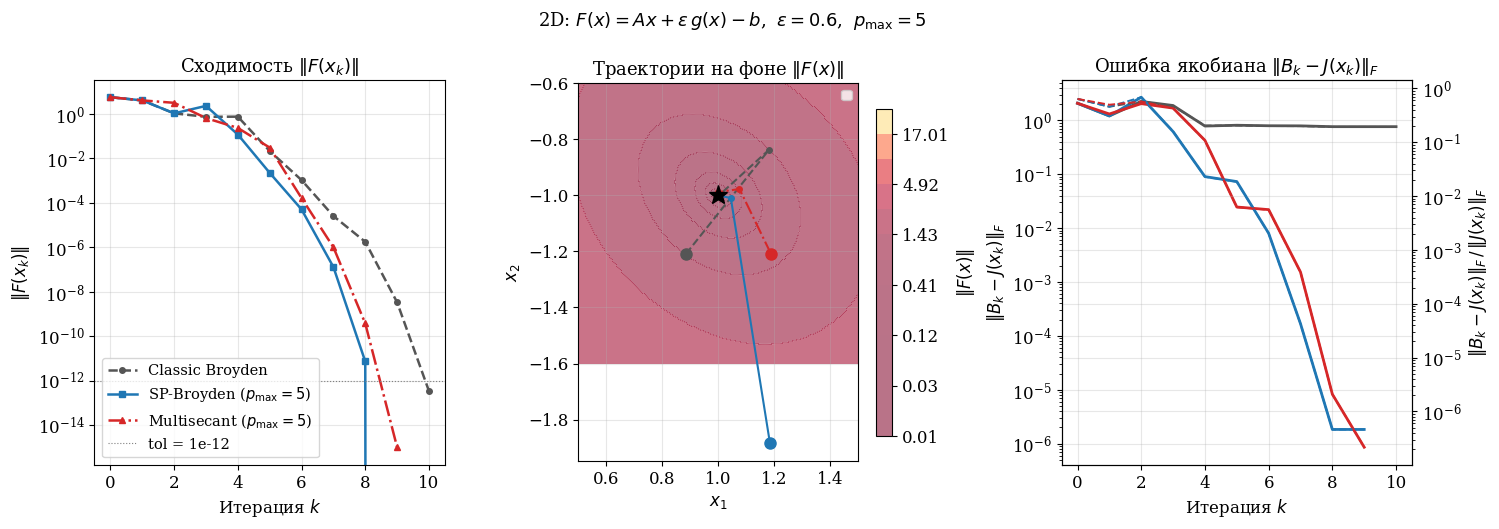

In [42]:
"""
2D пример: SP-Broyden vs Multisecant Broyden vs Classic Broyden
3 subplot'а в ряд:
  1. Сходимость ||F(x_k)||
  2. Траектории x_k на фоне контуров ||F(x)||
  3. Ошибка якобиана ||B_k - J(x_k)||_F  и  ||B_k - J(x_k)||_F / ||J(x_k)||_F
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10.5,
    "lines.linewidth": 1.8,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

MAX_ITER = 60
TOL      = 1e-12
TAU      = 1e8

# ── задача ────────────────────────────────────────────────────────────────────
A      = np.array([[2.0, 0.5],
                   [0.3, 1.8]])
eps    = 0.89
x_star = np.array([1.0, -1.0])

def g(x):
    return np.array([np.sin(x[0] + 0.5 * x[1]),
                     np.cos(0.4 * x[0] - x[1])])

def Dg(x):
    """Якобиан g(x), аналитически."""
    c1 = np.cos(x[0] + 0.5 * x[1])
    s2 = -np.sin(0.4 * x[0] - x[1])
    return np.array([[c1,       0.5 * c1],
                     [0.4 * s2, -s2     ]])

b = A @ x_star + eps * g(x_star)

def F(x):
    return A @ x + eps * g(x) - b

def J(x):
    """Точный якобиан F(x)."""
    return A + eps * Dg(x)

x0 = np.array([-1.5, 2.0])

# ══════════════════════════════════════════════════════════════════════════════
# Методы — возвращают (history_F, history_B_err, history_B_relerr, trajectory)
# ══════════════════════════════════════════════════════════════════════════════

def run_classic(x0):
    x = x0.copy().astype(float)
    B = np.eye(2)
    hF, hE, hR, traj = [np.linalg.norm(F(x))], [], [], [x.copy()]
    Jx = J(x)
    hE.append(np.linalg.norm(B - Jx, 'fro'))
    hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
    for _ in range(MAX_ITER):
        Fx = F(x)
        if np.linalg.norm(Fx) < TOL: break
        d = np.linalg.solve(B, -Fx)
        xn = x + d
        s = d; y = F(xn) - Fx
        denom = s @ s
        if abs(denom) > 1e-14:
            B = B + np.outer(y - B @ s, s) / denom
        x = xn
        traj.append(x.copy())
        hF.append(np.linalg.norm(F(x)))
        Jx = J(x)
        hE.append(np.linalg.norm(B - Jx, 'fro'))
        hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
        if hF[-1] < TOL: break
    return np.array(hF), np.array(hE), np.array(hR), np.array(traj)


def run_sp(x0, p_max=5, tau=TAU):
    x = x0.copy().astype(float)
    B = np.eye(2)
    steps = []
    hF, hE, hR, traj = [np.linalg.norm(F(x))], [], [], [x.copy()]
    Jx = J(x)
    hE.append(np.linalg.norm(B - Jx, 'fro'))
    hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
    for _ in range(MAX_ITER):
        Fx = F(x)
        if np.linalg.norm(Fx) < TOL: break
        d = np.linalg.solve(B, -Fx)
        xn = x + d
        s = d.copy(); y = F(xn) - Fx
        steps.insert(0, s)
        p = 0
        for p_try in range(1, min(p_max, len(steps)) + 1):
            Sp = np.column_stack(steps[:p_try])
            if np.linalg.cond(Sp.T @ Sp) < tau:
                p = p_try
            else:
                break
        print(p)
        if p == 0:
            v = s
        else:
            Sp = np.column_stack(steps[:p])
            e1 = np.zeros(p); e1[0] = 1.0
            v = Sp @ np.linalg.solve(Sp.T @ Sp, e1)
        vts = v @ s
        if abs(vts) < 1e-14: v = s; vts = s @ s
        B = B + np.outer(y - B @ s, v) / vts
        x = xn
        traj.append(x.copy())
        hF.append(np.linalg.norm(F(x)))
        Jx = J(x)
        hE.append(np.linalg.norm(B - Jx, 'fro'))
        hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
        if hF[-1] < TOL: break
    return np.array(hF), np.array(hE), np.array(hR), np.array(traj)


def run_multi(x0, p_max=2):
    x = x0.copy().astype(float)
    B = np.eye(2)
    steps, ys = [], []
    hF, hE, hR, traj = [np.linalg.norm(F(x))], [], [], [x.copy()]
    Jx = J(x)
    hE.append(np.linalg.norm(B - Jx, 'fro'))
    hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
    for _ in range(MAX_ITER):
        Fx = F(x)
        if np.linalg.norm(Fx) < TOL: break
        d = np.linalg.solve(B, -Fx)
        xn = x + d
        s = d.copy(); y = F(xn) - Fx
        steps.insert(0, s); ys.insert(0, y)
        p = min(p_max, len(steps))
        for p_try in range(1, min(p_max, len(steps)) + 1):
            Sp = np.column_stack(steps[:p_try])
            if np.linalg.cond(Sp.T @ Sp) < TAU:
                p = p_try
            else:
                break
        print(p)
        Sp = np.column_stack(steps[:p])
        Yp = np.column_stack(ys[:p])
        try:
            pseudo = Sp.T @ np.linalg.solve(Sp @ Sp.T, np.eye(2))
            B = B + (Yp - B @ Sp) @ pseudo
        except np.linalg.LinAlgError:
            denom = s @ s
            if abs(denom) > 1e-14:
                B = B + np.outer(y - B @ s, s) / denom
        x = xn
        traj.append(x.copy())
        hF.append(np.linalg.norm(F(x)))
        Jx = J(x)
        hE.append(np.linalg.norm(B - Jx, 'fro'))
        hR.append(hE[-1] / np.linalg.norm(Jx, 'fro'))
        if hF[-1] < TOL: break
    return np.array(hF), np.array(hE), np.array(hR), np.array(traj)


hF_c, hE_c, hR_c, traj_c = run_classic(x0)
hF_s, hE_s, hR_s, traj_s = run_sp(x0)
hF_m, hE_m, hR_m, traj_m = run_multi(x0)

# ══════════════════════════════════════════════════════════════════════════════
# Фигура: 1 строка, 3 широких subplot'а
# ══════════════════════════════════════════════════════════════════════════════
COLORS = {"classic": "#555555", "sp": "#1f77b4", "multi": "#d62728"}

fig = plt.figure(figsize=(17, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.38)

# ─── 1. Сходимость ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.semilogy(hF_c, color=COLORS["classic"], ls="--", marker="o", ms=4, label="Classic Broyden")
ax1.semilogy(hF_s, color=COLORS["sp"],      ls="-",  marker="s", ms=4, label=r"SP-Broyden ($p_{\max}=5$)")
ax1.semilogy(hF_m, color=COLORS["multi"],   ls="-.", marker="^", ms=4, label=r"Multisecant ($p_{\max}=5$)")
ax1.axhline(TOL, color="gray", lw=0.8, ls=":", label=f"tol = {TOL:.0e}")
ax1.set_title(r"Сходимость $\|F(x_k)\|$")
ax1.set_xlabel(r"Итерация $k$")
ax1.set_ylabel(r"$\|F(x_k)\|$")
ax1.legend()

# ─── 2. Траектории на фоне контуров ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_aspect("equal")

# контуры ||F(x)||
x1g = np.linspace(0.5, 1.5, 300)
x2g = np.linspace(-0.6, -1.6, 300)
X1, X2 = np.meshgrid(x1g, x2g)
Z = np.array([[np.linalg.norm(F(np.array([X1[i,j], X2[i,j]])))
               for j in range(300)] for i in range(300)])
levels = np.logspace(-2, 1.5, 14)
cf = ax2.contourf(X1, X2, Z, levels=levels, cmap="YlOrRd_r", alpha=0.55)
ax2.contour(X1, X2, Z, levels=levels, colors="white", linewidths=0.4, alpha=0.5)
plt.colorbar(cf, ax=ax2, label=r"$\|F(x)\|$", shrink=0.85)

def plot_traj(ax, traj, color, label, ls="-"):
    ax.plot(traj[:, 0], traj[:, 1], color=color, ls=ls,
            lw=1.5, marker="o", ms=4, zorder=3)
    ax.plot(traj[0, 0], traj[0, 1], "o", color=color, ms=8, zorder=4)
    ax.plot(traj[-1,0], traj[-1,1], "*", color=color, ms=10, zorder=4)

plot_traj(ax2, traj_c[3:], COLORS["classic"], "Classic Broyden",       ls="--")
plot_traj(ax2, traj_s[3:], COLORS["sp"],      r"SP-Broyden",           ls="-")
plot_traj(ax2, traj_m[3:], COLORS["multi"],   r"Multisecant",          ls="-.")
ax2.plot(*x_star, "k*", ms=14, zorder=5)
# ax2.plot(*x0,     "ks", ms=8,  zorder=5, label=r"$x_0$")
ax2.set_title(r"Траектории на фоне $\|F(x)\|$")
ax2.set_xlabel(r"$x_1$"); ax2.set_ylabel(r"$x_2$")
ax2.legend(loc="upper right", fontsize=9.5)

# ─── 3. Ошибка якобиана (две шкалы) ──────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3b = ax3.twinx()

lns = []
for hE, hR, color, label in [
        (hE_c, hR_c, COLORS["classic"], "Classic"),
        (hE_s, hR_s, COLORS["sp"],      "SP-Broyden"),
        (hE_m, hR_m, COLORS["multi"],   "Multisecant")]:
    l1, = ax3.semilogy(hE, color=color, ls="-",  lw=2,   label=label + r"  $\|\cdot\|_F$")
    l2, = ax3b.semilogy(hR, color=color, ls="--", lw=1.4, label=label + r"  (отн.)")
    # lns += [l1, l2]
    # pass

ax3.set_title(r"Ошибка якобиана $\|B_k - J(x_k)\|_F$")
ax3.set_xlabel(r"Итерация $k$")
ax3.set_ylabel(r"$\|B_k - J(x_k)\|_F$",      color="black")
ax3b.set_ylabel(r"$\|B_k - J(x_k)\|_F\,/\,\|J(x_k)\|_F$", color="black")
# ax3.legend(lns, [l.get_label() for l in lns],
#            loc="upper right", fontsize=9, ncol=1)

fig.suptitle(
    r"2D: $F(x)=Ax+\varepsilon\,g(x)-b$, $\;\varepsilon=0.6$, $\;p_{\max}=5$",
    fontsize=13, y=1.02)

plt.savefig("broyden_2d.png", dpi=150, bbox_inches="tight")
print("Сохранено: broyden_2d.png")

def iters(h):
    idx = np.where(h < TOL)[0]
    return idx[0] if len(idx) else f">{MAX_ITER}"

print(f"\nClassic  : {iters(hF_c)} итер,  "
      f"||B-J||_F финал = {hE_c[-1]:.2e},  отн. = {hR_c[-1]:.2e}")
print(f"SP       : {iters(hF_s)} итер,  "
      f"||B-J||_F финал = {hE_s[-1]:.2e},  отн. = {hR_s[-1]:.2e}")
print(f"Multisec : {iters(hF_m)} итер,  "
      f"||B-J||_F финал = {hE_m[-1]:.2e},  отн. = {hR_m[-1]:.2e}")
